In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Create a local directory to store the unpacked frames
!mkdir -p /content/frames_unpacked

# Unzip the file from Drive to the fast local storage
!unzip /content/drive/MyDrive/sdd_subset_frames.zip -d /content/frames_unpacked

Streaming output truncated to the last 5000 lines.
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_001029.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000337.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000860.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000874.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000684.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000690.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000848.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000109.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000647.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000121.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000135.png  
  inflating: /content/frames_unpacked/frames/nexus/video11/frame_000653.png  
  inflating: 

In [ ]:
import os, itertools

for root, dirs, files in itertools.islice(os.walk("/content/frames_unpacked"), 0, 10):
    print(root)
    for d in dirs[:5]:
        print("  dir:", d)
    for f in files[:5]:
        print("  file:", f)
    print("----")


/content/frames_unpacked
  dir: __MACOSX
  dir: frames
----
/content/frames_unpacked/__MACOSX
  dir: frames
----
/content/frames_unpacked/__MACOSX/frames
  dir: coupa
  dir: bookstore
  file: ._.DS_Store
----
/content/frames_unpacked/__MACOSX/frames/coupa
  dir: video0
  file: ._.DS_Store
----
/content/frames_unpacked/__MACOSX/frames/coupa/video0
  file: ._frame_000001.png
  file: ._frame_000002.png
----
/content/frames_unpacked/__MACOSX/frames/bookstore
  file: ._.DS_Store
----
/content/frames_unpacked/frames
  dir: nexus
  dir: coupa
  dir: bookstore
  file: .DS_Store
----
/content/frames_unpacked/frames/nexus
  dir: video5
  dir: video8
  dir: video11
  dir: video1
  dir: video7
----
/content/frames_unpacked/frames/nexus/video5
  file: frame_000076.png
  file: frame_000105.png
  file: frame_000090.png
  file: frame_000010.png
  file: frame_000068.png
----
/content/frames_unpacked/frames/nexus/video8
  file: frame_000076.png
  file: frame_000122.png
  file: frame_000708.png
  file: f

# 1. Dataset for next-frame prediction

# Saving parameters to google cloud for training


# Model definition and checkpoints
- Core classes
- training logic

In [3]:
import os, math, glob, shutil
from pathlib import Path
from contextlib import nullcontext
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils

from tqdm.auto import tqdm

# --- CONFIGURATION
SEQUENCE_LENGTH = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Use the checkpoint path defined in the setup cell
DRIVE_PROJECT_ROOT = '/content/drive/MyDrive/SDD_Project/diffusion_checkpoints'
FRAMES_ROOT = "/content/frames_unpacked/frames"
CHECKPOINT_PATH = os.path.join(DRIVE_PROJECT_ROOT, "sdd_cddpm_checkpoint.pth")
FINAL_MODEL_PATH = os.path.join(DRIVE_PROJECT_ROOT, "sdd_cddpm_final_model.pth")
EMA_MODEL_PATH = os.path.join(DRIVE_PROJECT_ROOT, "sdd_cddpm_final_ema.pth")


# Dataset
class NextFrameDataset(Dataset):
    def __init__(self, frames_root, seq_len=5):
        super().__init__()
        self.frames_root = Path(frames_root)
        self.seq_len = seq_len
        self.transform = T.Compose([
            T.ToTensor(),
            T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        self.samples = []
        self._build_index()
        print(f"[INFO] Dataset built with {len(self.samples)} samples — SeqLen={seq_len}")

    def _build_index(self):
        for scene_dir in sorted(self.frames_root.iterdir()):
            if not scene_dir.is_dir(): continue
            for video_dir in sorted(scene_dir.iterdir()):
                if not video_dir.is_dir(): continue
                frame_paths = sorted(glob.glob(str(video_dir / "frame_*.png")))
                if len(frame_paths) <= self.seq_len: continue
                for i in range(len(frame_paths) - self.seq_len):
                    in_paths = frame_paths[i:i+self.seq_len]
                    tgt_path = frame_paths[i+self.seq_len]
                    self.samples.append((in_paths, tgt_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        in_paths, tgt_path = self.samples[idx]
        inputs = [self.transform(Image.open(p).convert("RGB")) for p in in_paths]
        x_cond_seq = torch.stack(inputs, dim=0)
        y = self.transform(Image.open(tgt_path).convert("RGB"))
        x_cond_flat = x_cond_seq.view(-1, *x_cond_seq.shape[2:])
        return x_cond_flat, y


def create_dataloader(frames_root, seq_len=SEQUENCE_LENGTH, batch_size=8, shuffle=True):
    dataset = NextFrameDataset(frames_root, seq_len=seq_len)
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, num_workers=4,
        pin_memory=(device.type == "cuda"), persistent_workers=False
    )
    return loader


# Diffusion
class DiffusionConfig:
    def __init__(self, timesteps=300):
        self.timesteps = timesteps
        def cosine_beta_schedule(T, s=0.008):
            t = torch.linspace(0, T, T+1)
            f = torch.cos(((t/T + s)/(1+s)) * torch.pi/2)**2
            alphabar = f / f[0]
            betas = 1 - (alphabar[1:] / alphabar[:-1])
            return betas.clamp(1e-6, 0.02)
        self.betas = cosine_beta_schedule(timesteps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), self.alphas_cumprod[:-1]], dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = (self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod))

def extract(a, t, x_shape):
    b = t.shape[0]
    out = a.gather(-1, t).float()
    return out.view(b, *((1,) * (len(x_shape) - 1)))


# Model Architecture
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.block1 = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.GroupNorm(8, out_ch), nn.SiLU())
        self.block2 = nn.Sequential(nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.GroupNorm(8, out_ch), nn.SiLU())
        self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.block1(x)
        t_added = self.time_mlp(t_emb)[:, :, None, None]
        h = h + t_added
        h = self.block2(h)
        return h + self.residual_conv(x)

class UNetCond(nn.Module):
    def __init__(self, img_channels=3, seq_len=SEQUENCE_LENGTH, base_channels=64, time_dim=128):
        super().__init__()
        cond_channels = seq_len * img_channels
        in_channels = img_channels + cond_channels
        self.time_mlp = nn.Sequential(SinusoidalPosEmb(time_dim), nn.Linear(time_dim, time_dim * 4), nn.SiLU(), nn.Linear(time_dim * 4, time_dim))
        self.down1 = ResidualBlock(in_channels, base_channels, time_dim)
        self.down2 = ResidualBlock(base_channels, base_channels * 2, time_dim)
        self.down3 = ResidualBlock(base_channels * 2, base_channels * 4, time_dim)
        self.pool = nn.AvgPool2d(2)
        self.mid = ResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.up3 = ResidualBlock(base_channels * 4 + base_channels * 4, base_channels * 2, time_dim)
        self.up2 = ResidualBlock(base_channels * 2 + base_channels * 2, base_channels, time_dim)
        self.up1 = ResidualBlock(base_channels + base_channels, base_channels, time_dim)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.final_conv = nn.Conv2d(base_channels, img_channels, 1)
    def forward(self, x_noisy, x_cond_flat, t):
        t_emb = self.time_mlp(t)
        x = torch.cat([x_noisy, x_cond_flat], dim=1)
        d1 = self.down1(x, t_emb)
        d2 = self.down2(self.pool(d1), t_emb)
        d3 = self.down3(self.pool(d2), t_emb)
        m  = self.mid(self.pool(d3), t_emb)
        u3 = self.up3(torch.cat([self.upsample(m), d3], dim=1), t_emb)
        u2 = self.up2(torch.cat([self.upsample(u3), d2], dim=1), t_emb)
        u1 = self.up1(torch.cat([self.upsample(u2), d1], dim=1), t_emb)
        return self.final_conv(u1)


# ---------- GLOBAL INITIALIZATION ----------
config = DiffusionConfig(timesteps=300)
model = UNetCond(seq_len=SEQUENCE_LENGTH, base_channels=64, time_dim=128).to(device)
ema_model = UNetCond(seq_len=SEQUENCE_LENGTH, base_channels=64, time_dim=128).to(device)
ema_model.load_state_dict(model.state_dict())
ema_decay = 0.999
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
start_epoch = 0

# move buffers to device
for attr in ['betas','alphas','alphas_cumprod','alphas_cumprod_prev',
             'sqrt_alphas_cumprod','sqrt_one_minus_alphas_cumprod','posterior_variance']:
    setattr(config, attr, getattr(config, attr).to(device))

# AMP setup
use_amp = (device.type == "cuda")

if use_amp:
    autocast_ctx = lambda: torch.amp.autocast(device_type='cuda')
else:
    autocast_ctx = lambda: nullcontext()

scaler = torch.amp.GradScaler(enabled=use_amp, device='cuda')


def load_checkpoint(filepath):
    global start_epoch
    if os.path.isfile(filepath):
        print(f"[CHECKPOINT] Loading checkpoint from {filepath}...")
        checkpoint = torch.load(filepath, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        ema_model.load_state_dict(checkpoint['ema_model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"[CHECKPOINT] Resuming training from epoch {start_epoch}.")
    else:
        print("[CHECKPOINT] No checkpoint found. Starting fresh.")


def save_checkpoint(filepath, epoch):
    """Saves model and optimizer state for resuming training."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'ema_model_state_dict': ema_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
    }
    torch.save(checkpoint, filepath)

    torch.save(model.state_dict(), FINAL_MODEL_PATH)
    torch.save(ema_model.state_dict(), EMA_MODEL_PATH)


@torch.no_grad()
def ema_update():
    for p, q in zip(model.parameters(), ema_model.parameters()):
        q.data.mul_(ema_decay).add_(p.data, alpha=1 - ema_decay)


def train_diffusion(num_epochs=30, batch_size=8, lambda_img=0.05):
    load_checkpoint(CHECKPOINT_PATH) # Attempt to load checkpoint
    loader = create_dataloader(FRAMES_ROOT, seq_len=SEQUENCE_LENGTH,
                               batch_size=batch_size, shuffle=True)
    model.train()

    # Iterate from the loaded start_epoch
    for epoch in range(start_epoch, num_epochs):
        running = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for step, (x_cond_flat, x0) in enumerate(pbar):
            x_cond_flat = x_cond_flat.to(device)
            x0 = x0.to(device)
            b = x0.size(0)
            t = torch.randint(0, config.timesteps, (b,), device=device).long()

            noise = torch.randn_like(x0)
            sqrt_a  = extract(config.sqrt_alphas_cumprod, t, x0.shape)
            sqrt_om = extract(config.sqrt_one_minus_alphas_cumprod, t, x0.shape)
            xt = sqrt_a * x0 + sqrt_om * noise

            with autocast_ctx():
                pred_noise = model(xt, x_cond_flat, t)
                x0_hat = (xt - sqrt_om * pred_noise) / (sqrt_a + 1e-8)
                loss = F.mse_loss(pred_noise, noise) + lambda_img * F.l1_loss(x0_hat, x0)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            ema_update()

            running += loss.item()
            if (step + 1) % 100 == 0:
                pbar.set_postfix(loss=f"{running/100:.4f}")
                running = 0.0

        print(f"[INFO] Epoch {epoch+1} complete. Saving checkpoint...")
        save_checkpoint(CHECKPOINT_PATH, epoch)

    print(f"[INFO] Training finished after {num_epochs} epochs. Final model saved to Drive.")

# --- Execute Training ---
if __name__ == "__main__":
    train_diffusion(num_epochs=30, batch_size=8, lambda_img=0.05)

[CHECKPOINT] Loading checkpoint from /content/drive/MyDrive/SDD_Project/diffusion_checkpoints/sdd_cddpm_checkpoint.pth...
[CHECKPOINT] Resuming training from epoch 30.
[INFO] Dataset built with 25921 samples — SeqLen=5
[INFO] Training finished after 30 epochs. Final model saved to Drive.


# Image generation
- Sampling
- Predicition
- Generation


# With Metrics and Stats


[INFO] Loading EMA Model from Drive: /content/drive/MyDrive/SDD_Project/diffusion_checkpoints/sdd_cddpm_final_ema.pth
[INFO] Dataset built with 25921 samples — SeqLen=5
[INFO] Dataset size: 25921 samples
Input paths: ['/content/frames_unpacked/frames/nexus/video10/frame_000571.png', '/content/frames_unpacked/frames/nexus/video10/frame_000572.png', '/content/frames_unpacked/frames/nexus/video10/frame_000573.png', '/content/frames_unpacked/frames/nexus/video10/frame_000574.png', '/content/frames_unpacked/frames/nexus/video10/frame_000575.png']
Target (F6) path: /content/frames_unpacked/frames/nexus/video10/frame_000576.png
Future GT paths (F6..F10): [PosixPath('/content/frames_unpacked/frames/nexus/video10/frame_000576.png'), PosixPath('/content/frames_unpacked/frames/nexus/video10/frame_000577.png'), PosixPath('/content/frames_unpacked/frames/nexus/video10/frame_000578.png'), PosixPath('/content/frames_unpacked/frames/nexus/video10/frame_000579.png'), PosixPath('/content/frames_unpacked

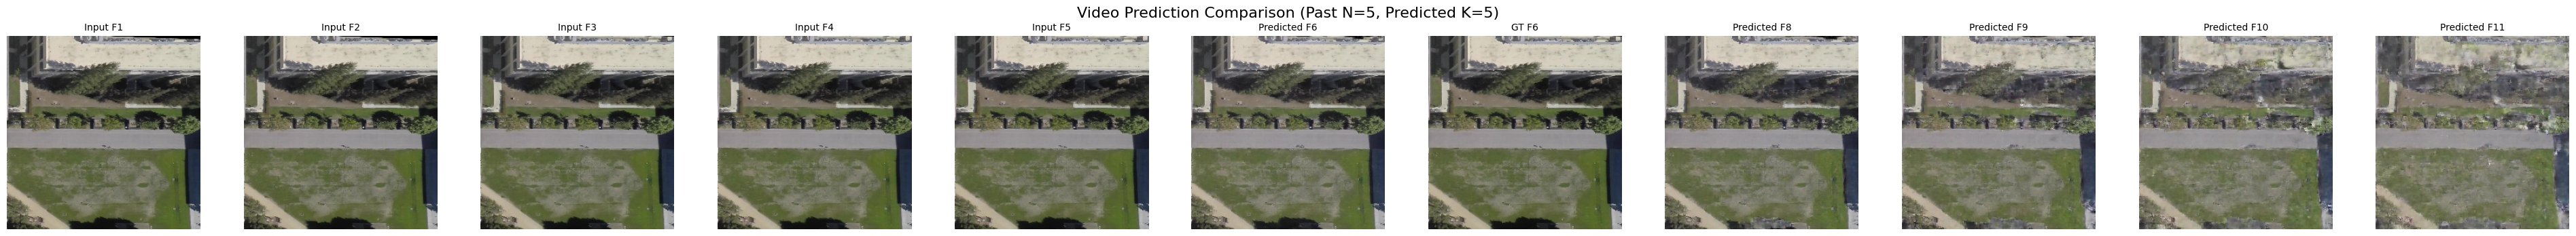

[INFO] Saved visualization grid to /content/next_frames_preview_final.png
[DONE]


In [6]:
import os, math
from pathlib import Path
from PIL import Image

import random
import torch
import torch.nn as nn
import torchvision.utils as vutils
import torchvision.transforms.functional as TF
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from contextlib import nullcontext


# ------------------ CONFIG ------------------
SEQUENCE_LENGTH = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DRIVE_PROJECT_ROOT = '/content/drive/MyDrive/SDD_Project/diffusion_checkpoints'
FRAMES_ROOT = "/content/frames_unpacked/frames"
EMA_MODEL_PATH = os.path.join(DRIVE_PROJECT_ROOT, "sdd_cddpm_final_ema.pth")

# Re-create diffusion config + model
config = DiffusionConfig(timesteps=300)
ema_model = UNetCond(seq_len=SEQUENCE_LENGTH, base_channels=64, time_dim=128).to(device)

# Move diffusion buffers to device
for attr in ['betas','alphas','alphas_cumprod','sqrt_alphas_cumprod','sqrt_one_minus_alphas_cumprod']:
    setattr(config, attr, getattr(config, attr).to(device))

# AMP setup
use_amp = (device.type == "cuda")
if use_amp:
    autocast_ctx = lambda: torch.amp.autocast(device_type='cuda')
else:
    autocast_ctx = lambda: nullcontext()



@torch.no_grad()
def ddim_sample_one(net, config, x_cond_flat, steps=50, eta=0.0, size=(3,256,256), device="cuda"):
    net.eval()
    B = x_cond_flat.size(0)
    C, H, W = size
    xt = torch.randn(B, C, H, W, device=device)
    T_tot = config.timesteps
    ts = torch.linspace(T_tot-1, 0, steps, dtype=torch.long, device=device)
    alphas_cum = config.alphas_cumprod

    for i in range(len(ts)-1):
        t      = ts[i].repeat(B)
        t_next = ts[i+1].repeat(B)
        with autocast_ctx():
            eps = net(xt, x_cond_flat, t)
        a_t    = extract(alphas_cum, t, xt.shape)
        a_next = extract(alphas_cum, t_next, xt.shape)
        x0_hat = (xt - torch.sqrt(1 - a_t) * eps) / (torch.sqrt(a_t) + 1e-8)
        sigma_t = eta * torch.sqrt((1 - a_next)/(1 - a_t) * (1 - a_t/a_next))
        dir_xt  = torch.sqrt(a_next) * x0_hat
        noise_xt = torch.sqrt(1 - a_next - sigma_t**2) * eps
        xt = dir_xt + noise_xt
        if eta > 0:
            xt = xt + sigma_t * torch.randn_like(xt)

    t = ts[-1].repeat(B)
    with autocast_ctx():
        eps = net(xt, x_cond_flat, t)
    a_t = extract(alphas_cum, t, xt.shape)
    x0_hat = (xt - torch.sqrt(1 - a_t) * eps) / (torch.sqrt(a_t) + 1e-8)
    return x0_hat.clamp(-1, 1)


@torch.no_grad()
def predict_next_k_frames(ema_net, config, past_seq, K=5, steps=50, device="cuda"):
    """
    Autoregressively predict K future frames.
    past_seq: (B, N, 3, H, W) in [-1,1]
    """
    ema_net.eval()
    B, N, C, H, W = past_seq.shape
    preds = []

    def flatten(frames):
        return frames.view(B, N*C, H, W)

    cur = past_seq.to(device)
    for _ in range(K):
        x_cond_flat = flatten(cur)
        x_next = ddim_sample_one(ema_net, config, x_cond_flat,
                                 steps=steps, eta=0.0,
                                 size=(C, H, W), device=device)
        preds.append(x_next)
        cur = torch.cat([cur[:, 1:], x_next.unsqueeze(1)], dim=1)
    return preds


def to01(x):
    """Convert from [-1,1] to [0,1]."""
    return (x.clamp(-1,1) + 1) * 0.5



def get_future_gt_paths_from_inpaths(in_paths, K):
    """
    Given the 5 input frame paths (F1..F5), construct paths for the next K frames (F6..F(5+K)).
    """
    last = Path(in_paths[-1])   # F5
    stem = last.stem
    prefix, idx_str = stem.split('_')
    start_idx = int(idx_str)
    dirpath = last.parent

    paths = []
    for k in range(1, K+1):
        p = dirpath / f"{prefix}_{start_idx + k:06d}.png"
        if not p.exists():
            break
        paths.append(p)
    return paths


@torch.no_grad()
def compute_frame_metrics(preds, gt_paths):
    """
    preds: list of length K, each tensor of shape (B, 3, H, W) in [-1,1]
    gt_paths: list of K Paths to ground-truth PNGs
    """
    to_tensor = T.ToTensor()
    mse_list, psnr_list = [], []

    for k, (pred, path) in enumerate(zip(preds, gt_paths)):
        gt = to_tensor(Image.open(path).convert('RGB'))      # (3,H,W), in [0,1]
        pred01 = to01(pred[0].cpu())                         # (3,H,W), in [0,1]


        _, H_gt, W_gt = gt.shape
        _, H_pr, W_pr = pred01.shape
        H = min(H_gt, H_pr)
        W = min(W_gt, W_pr)
        gt_c   = gt[:, :H, :W]
        pred_c = pred01[:, :H, :W]

        mse = torch.mean((pred_c - gt_c) ** 2).item()
        mse_list.append(mse)
        psnr = 10 * math.log10(1.0 / mse) if mse > 0 else float('inf')
        psnr_list.append(psnr)

        print(f"Frame F{6 + k}: MSE={mse:.6f}, PSNR={psnr:.2f} dB, GT={path.name}")

    mean_mse  = sum(mse_list) / len(mse_list)
    mean_psnr = sum(psnr_list) / len(psnr_list)

    print(f"\n[METRICS] Mean MSE over {len(mse_list)} frames: {mean_mse:.6f}")
    print(f"[METRICS] Mean PSNR over {len(psnr_list)} frames: {mean_psnr:.2f} dB\n")

    return mse_list, psnr_list



def save_preview_grid(past_seq, preds, y_gt_f6, out_path):
    """
    Save a visualization grid: Past frames + Predicted frames + Ground Truth F6.
    """
    B, N, C, H, W = past_seq.shape
    past = to01(past_seq[0].cpu())          # (N,3,H,W)
    K = len(preds)

    future = torch.stack([to01(p[0].cpu()) for p in preds], dim=0)  # (K,3,H,W)
    gt_f6 = to01(y_gt_f6[0].cpu()).unsqueeze(0)                     # (1,3,H,W)

    # Sequence: F1..F5 | Pred F6 | GT F6 | Pred F7..F(5+K-1)
    visualization_sequence = [past,
                              future[0].unsqueeze(0),
                              gt_f6] + [future[i].unsqueeze(0) for i in range(1, K)]

    combined = torch.cat(visualization_sequence, dim=0)

    images = [TF.to_pil_image(img) for img in combined]
    cols = N + K + 1
    fig, axes = plt.subplots(1, cols, figsize=(3.5 * cols, 3.5))

    titles = [f"Input F{i+1}" for i in range(N)] + \
             ["Predicted F6"] + \
             ["GT F6"] + \
             [f"Predicted F{i+1}" for i in range(7, 7 + K - 1)]

    for i in range(cols):
        axes[i].imshow(images[i])
        axes[i].axis('off')
        axes[i].set_title(titles[i], fontsize=10)

    plt.suptitle(f"Video Prediction Comparison (Past N={N}, Predicted K={K})", fontsize=16)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()

    print(f"[INFO] Saved visualization grid to {out_path}")


# ------------------ EXECUTION ------------------
if __name__ == "__main__":
    if not os.path.exists(EMA_MODEL_PATH):
        print(f"[ERROR] EMA Model not found at {EMA_MODEL_PATH}. Run training first!")
    else:
        print(f"[INFO] Loading EMA Model from Drive: {EMA_MODEL_PATH}")
        ema_model.load_state_dict(torch.load(EMA_MODEL_PATH, map_location=device))

        # change idx to sample another scene
        dataset = NextFrameDataset(FRAMES_ROOT, seq_len=SEQUENCE_LENGTH)
        print(f"[INFO] Dataset size: {len(dataset)} samples")

        idx = random.randint(0, len(dataset)-1)
        x_cond_flat, y_gt = dataset[idx]

        # Add batch dimension and reshape into (B,N,3,H,W)
        x_cond_flat = x_cond_flat.unsqueeze(0).to(device)  # (1, seq*3, H, W)
        y_gt        = y_gt.unsqueeze(0).to(device)         # (1, 3, H, W)
        B, _, H, W  = x_cond_flat.shape
        C = 3
        past_seq = x_cond_flat.view(B, SEQUENCE_LENGTH, C, H, W)

        # Predict next K frames
        K = 5
        preds = predict_next_k_frames(ema_model, config, past_seq,
                                      K=K, steps=50, device=device)

        # Metrics: get ground-truth paths F6..F10
        in_paths, tgt_path = dataset.samples[idx]
        gt_future_paths = get_future_gt_paths_from_inpaths(in_paths, K)

        print("Input paths:", in_paths)
        print("Target (F6) path:", tgt_path)
        print("Future GT paths (F6..F10):", gt_future_paths)

        # Compute MSE + PSNR against all available GT future frames
        compute_frame_metrics(preds[:len(gt_future_paths)], gt_future_paths)

        # Visualization grid using F1..F5, Pred F6..F10, and GT F6
        save_preview_grid(
            past_seq.cpu(),
            preds,
            y_gt.cpu(),   # Ground truth F6 from dataset
            os.path.join("/content", "next_frames_preview_final.png")
        )

        print("[DONE]")
